In [20]:
%pip install matplotlib
%pip install pandas
%pip install scikit-learn
%pip install numpy 
%pip install sympy
%pip install tensorflow
%pip install keras

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sympy.solvers.solveset import linsolve
from sympy import symbols


# Data Loading and Exploration

I begin the project by importing the necessary libraries

In [22]:
plt.style.use('ggplot')

In [23]:
#Had to sort the data as it was not in order of x values, which is important for plotting and training the model

train_data = pd.read_csv('train.csv')
train_data.sort_values('x', inplace=True)

x_train = train_data.x.to_numpy()
y_train = train_data.y.to_numpy()

validation_dataset = pd.read_csv('val.csv')
validation_dataset.sort_values('x', inplace=True)

x_val = validation_dataset.x.to_numpy()
y_val = validation_dataset.y.to_numpy()


The data seems to fit a polynomial distribution with some noise as can be seen from the scatter plot below.
Validation dataset less clustered, due to less data (4x less). 
Both datasets have very similar shape.


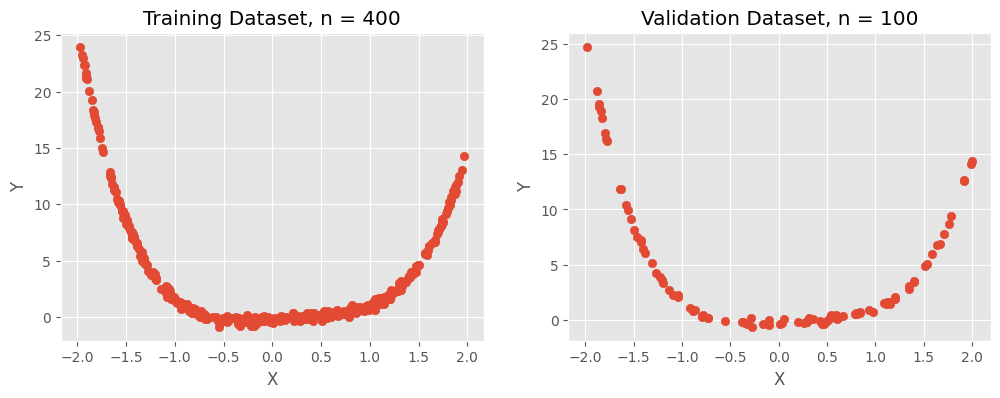

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(x_train, y_train)
axs[0].set_title(f'Training Dataset, n = {x_train.size}')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')

axs[1].scatter(x_val, y_val)
axs[1].set_title(f'Validation Dataset, n = {x_val.size}')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')

# plt.tight_layout()

plt.show()

## Polynomial Regression

In [25]:
#We are told the polynomial is of degree 4 
poly = PolynomialFeatures(degree=4, include_bias=False)
poly_features = poly.fit_transform(x_train.reshape(-1, 1))

In [26]:
poly_features = poly.fit_transform(x_train.reshape(-1, 1))

In [27]:
# x_train.reshape(-1, 1)

In [28]:
# poly.transform(x.reshape(-1, 1))

In [29]:
from sklearn.linear_model import LinearRegression

poly_reg_model = LinearRegression()
poly_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
params = poly_reg_model.fit(poly_features, y_train)

y_predicted = poly_reg_model.predict(poly_features)
# print(y_predicted[:10])
# print(y[:10])


In [31]:
a_1, a_2, a_3, a_4 = params.coef_

a_0 = params.intercept_

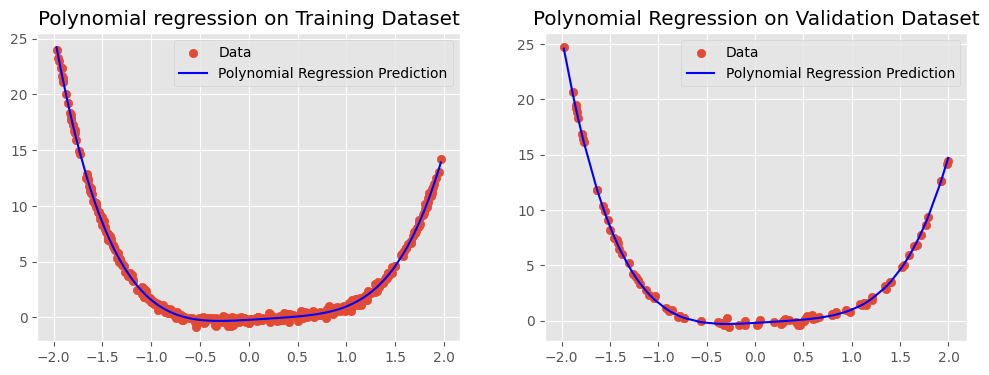

[ 0.51  0.29 -0.8   1.21 -0.21]
MSE on Training Dataset: 0.04225038507930524
MSE on Validation Dataset: 0.0307308080692367


In [32]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

#----------------------------------------------------------------------------------------------------------------------------
#test_data_pred
train_data_pred = [a_0 + a_1*x + a_2*x**2 + a_3*x**3 + a_4*x**4 for x in x_train]

# plt.scatter(x, y)
data = axs[0].scatter(x_train, y_train, label='Data')
prediction = axs[0].plot(x_train, train_data_pred, c='blue', label='Polynomial Regression Prediction')
axs[0].set_title('Polynomial regression on Training Dataset')
axs[0].legend()

#----------------------------------------------------------------------------------------------------------------------------
#validation_data_pred


validation_data_pred = [a_0 + a_1*x + a_2*x**2 + a_3*x**3 + a_4*x**4 for x in x_val]
axs[1].scatter(x_val, y_val, label='Data')
axs[1].plot(x_val, validation_data_pred, c='blue', label='Polynomial Regression Prediction')
axs[1].legend()


axs[1].set_title('Polynomial Regression on Validation Dataset')

plt.show()

from sklearn.metrics import mean_squared_error

polynomial_mse_train = mean_squared_error(train_data_pred, y_train)
polynomial_mse_val = mean_squared_error(validation_data_pred, y_val)

# print([round(coeff, 2) for coeff in poly_reg_model.coef_])
print(np.round(np.append(poly_reg_model.coef_, poly_reg_model.intercept_), 2))
print(f'MSE on Training Dataset: {polynomial_mse_train}')
print(f'MSE on Validation Dataset: {polynomial_mse_val}')



0.03806992162512612


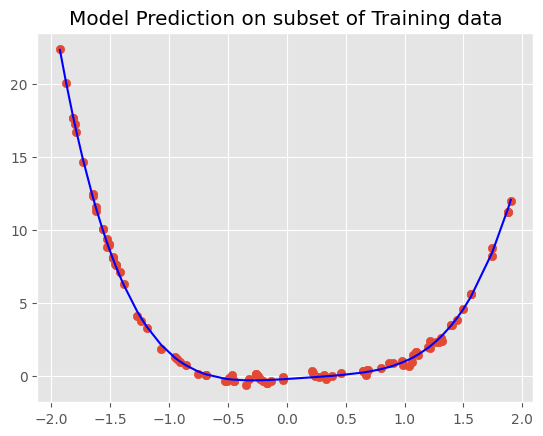

In [33]:
#Validation MSE is smaller than the training. The aim of this code is to take a subset of 
#training data equal in size to validation data and see how MSE differs
x_train_reduced = np.sort(np.random.choice(x_train, 100))
y_train_reduced = []

for x in x_train_reduced:
    x_train_ls = list(x_train)
    idx = x_train_ls.index(x)
    y_train_reduced.append(y_train[idx])
    
plt.scatter(x_train_reduced, y_train_reduced)

y_reduced_pred = [a_0 + a_1*x + a_2*x**2 + a_3*x**3 + a_4*x**4 for x in x_train_reduced]

plt.plot(x_train_reduced, y_reduced_pred, color='blue')
plt.title('Model Prediction on subset of Training data')
print(mean_squared_error(y_train_reduced, y_reduced_pred))
    

## MLP

In [37]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

train_data = pd.read_csv('train.csv')
train_data.sort_values('x', inplace=True)

x_train = train_data.x.to_numpy()
y_train = train_data.y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(x_train.reshape(-1, 1), y_train.reshape(-1, 1))

mlp_reg = MLPRegressor(hidden_layer_sizes=(32, 32), 
                       activation='relu',
                       solver='adam',
                       max_iter=1000)

mlp_reg.fit(X_train, y_train)


c:\Users\richa_6\Data Science Leeds\Year 2\MATH2603\individual_summative\MATH2603_individual_summative\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\richa_6\Data Science Leeds\Year 2\MATH2603\individual_summative\MATH2603_individual_summative\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [38]:
mlp_reg_y_pred = mlp_reg.predict(X_test)

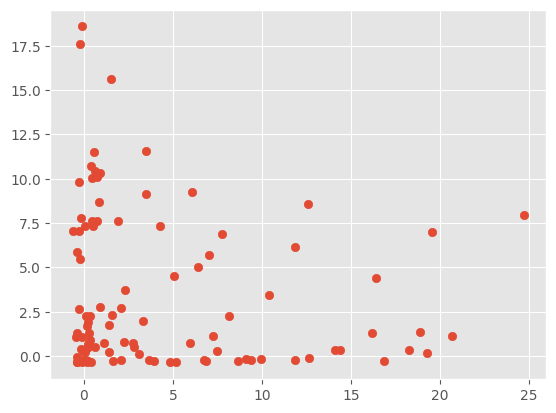

In [39]:
plt.scatter(y_val, mlp_reg_y_pred)

In [ ]:
X, y = np.array(x_train, dtype='float32'), y_train

type(X[0])

numpy.float32

In [ ]:
#Dummy git commit